# Pairwise significance and heatmaps

This notebook compares paired experimental settings on the same test cases:

1. Load `predictions.csv` files from `runs/final_run`.
2. Run a paired bootstrap (and McNemar) test on overlapping ids.
3. Plot ΔF1 heatmaps (HateCheck / Reddit / Bulgaria stacked in each cell).
4. Write CSV results used by the Overleaf table script.

A star in a cell means bootstrap $p<0.05$. Color is the mean ΔF1 (percentage points) across the three dataset variants, unless noted.

Paper LaTeX tables are generated separately by `reports/overleaf paper/scripts/generate_pairwise_delta_tables.py`.

**Inputs:** `runs/final_run/{dataset}/{model}/{definition}/{prompting}/predictions.csv`

**Outputs:**
- `tables/*_significance_test.csv` — full pairwise test results
- `figures/delta_f1_*.pdf` — heatmaps


## Setup

Paths, experiment grid, shared test/plot helpers, and prediction loading.


In [38]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binom, chi2
from tqdm.auto import tqdm

PROJECT_ROOT = Path("..").resolve()
RUN_DIR = PROJECT_ROOT / "runs" / "final_run"
TABLES_DIR = Path("tables")
FIGURES_DIR = Path("figures")
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
DATASETS = {
    "hatecheck": {"label": "HateCheck", "short": "HC"},
    "hatecheck_reddit": {"label": "Reddit", "short": "R"},
    "hatecheck_bulgaria": {"label": "Bulgaria", "short": "B"},
}
SCOPES = {
    "no_definition": {
        "hatecheck": "hatecheck_no_definition",
        "hatecheck_reddit": "reddit_no_definition",
        "hatecheck_bulgaria": "bulgaria_no_definition",
    },
    "hsc": {
        "hatecheck": "hatecheck_hsc",
        "hatecheck_reddit": "reddit_hsc",
        "hatecheck_bulgaria": "bulgaria_hsc",
    },
}
SCOPE_LABEL = {"no_definition": "No Definition", "hsc": "HSC"}
SCOPE_TEX = {"no_definition": r"\texttt{No Def.}", "hsc": r"\texttt{HSC}"}
EXPERIMENT_SPECS = {ds: [SCOPES["no_definition"][ds], SCOPES["hsc"][ds]] for ds in DATASETS}
EXPERIMENT_SPECS["hatecheck_bulgaria"].append("bulgaria_hsc_target_excluded")

MODELS = {
    "gemma2_2b_it": {"label": "Gemma 2", "tex": r"\texttt{Gemma-2}", "file": "gemma"},
    "llama3_2_3b_instruct": {"label": "Llama 3.2", "tex": r"\texttt{Llama-3.2}", "file": "llama"},
    "qwen2_5_3b_instruct": {"label": "Qwen 2.5", "tex": r"\texttt{Qwen2.5}", "file": "qwen"},
}
MODEL_IDS = list(MODELS)
MODEL_PAIR_IDS = ["gemma2_2b_it", "qwen2_5_3b_instruct", "llama3_2_3b_instruct"]

PROMPTINGS = {
    "zero-shot": {"label": "Zero-shot", "short": "ZS"},
    "few-shot-random": {"label": "Few-shot Random", "short": "FR"},
    "few-shot-diverse": {"label": "Few-shot Diverse", "short": "FD"},
    "few-shot-nearest-query": {"label": "Few-shot Nearest", "short": "FN"},
}
PROMPTING_IDS = list(PROMPTINGS)

HSC_VS_NO_DEF = {ds: f"{SCOPES['hsc'][ds]} vs {SCOPES['no_definition'][ds]}" for ds in DATASETS}
DEFINITION_PAIRS = [(SCOPES["hsc"][ds], SCOPES["no_definition"][ds]) for ds in DATASETS]
DATASET_BY_DEFINITION = {
    definition: dataset
    for dataset, definitions in EXPERIMENT_SPECS.items()
    for definition in definitions
}

# Derived aliases used by later cells (ids for loops, labels for display).
FINAL_RUN = RUN_DIR
MODEL_INFO = MODELS
MODEL_LABELS = {k: v["label"] for k, v in MODEL_INFO.items()}
MODEL_TEX = {k: v["tex"] for k, v in MODEL_INFO.items()}
MODELS = MODEL_IDS
MODEL_PAIR_ORDER = MODEL_PAIR_IDS
PROMPTING_INFO = PROMPTINGS
PROMPTING_LABELS = {k: v["label"] for k, v in PROMPTING_INFO.items()}
PROMPTING_SHORT = {k: v["short"] for k, v in PROMPTING_INFO.items()}
PROMPTING_TEX = {k: rf"\texttt{{{v['label']}}}" for k, v in PROMPTING_INFO.items()}
PROMPTINGS = PROMPTING_IDS
MERGED_DEFINITION_KEYS = list(SCOPES)
MERGED_DEFINITION_LABELS = SCOPE_LABEL
MERGED_DEFINITION_TEX = SCOPE_TEX
DEFINITION_BY_DATASET = SCOPES
MAIN_DATASETS = [(ds, meta["label"]) for ds, meta in DATASETS.items()]
MAIN_DATASETS_SHORT = [(ds, meta["short"]) for ds, meta in DATASETS.items()]

HEATMAP_LABEL_FONTSIZE = 16
HEATMAP_CELL_FONTSIZE = 13.5
N_BOOTSTRAP = 10_000
LABEL_TO_INT = {"non-hateful": 0, "hateful": 1}

In [11]:
def upper_pairs(items):
    """Unordered pairs with a stable A vs B order (reversed list, i < j)."""
    rev = list(reversed(list(items)))
    for i, a in enumerate(rev):
        for b in rev[i + 1 :]:
            yield a, b


def encode_binary_labels(values) -> np.ndarray:
    unknown = set(values) - LABEL_TO_INT.keys()
    if unknown:
        raise ValueError(f"Unsupported labels: {sorted(unknown)}")
    return np.array([LABEL_TO_INT[v] for v in values], dtype=np.int8)


def _f1_from_counts(tp, fp, fn) -> float:
    denom = 2 * tp + fp + fn
    return (2 * tp / denom) if denom > 0 else 0.0


def binary_macro_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    tp1 = np.sum((y_true == 1) & (y_pred == 1))
    fp1 = np.sum((y_true == 0) & (y_pred == 1))
    fn1 = np.sum((y_true == 1) & (y_pred == 0))
    tp0 = np.sum((y_true == 0) & (y_pred == 0))
    return (_f1_from_counts(tp0, fn1, fp1) + _f1_from_counts(tp1, fp1, fn1)) / 2


def mcnemar_p_value(b_count: int, c_count: int) -> float:
    n_discordant = b_count + c_count
    if n_discordant == 0:
        return 1.0
    if n_discordant < 25:
        return float(
            2
            * min(
                binom.cdf(b_count, n_discordant, 0.5),
                binom.sf(b_count - 1, n_discordant, 0.5),
            )
        )
    stat = (abs(b_count - c_count) - 1) ** 2 / n_discordant
    return float(chi2.sf(stat, df=1))


def paired_significance(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    *,
    n_bootstrap: int = N_BOOTSTRAP,
    ci: float = 0.95,
    seed: int = 42,
    require_same_gold: bool = True,
) -> dict:
    """Paired bootstrap ΔF1 (A − B) and McNemar test on overlapping sample ids."""
    cols = ["id", "label", "prediction"]
    merged = df_a[cols].merge(df_b[cols], on="id", how="inner", suffixes=("_a", "_b"))
    if merged.empty:
        raise ValueError("No overlapping sample ids between the two prediction files.")

    label_mismatch = merged["label_a"] != merged["label_b"]
    if require_same_gold and label_mismatch.any():
        raise ValueError(
            f"Gold labels disagree on {int(label_mismatch.sum())} shared ids."
        )

    y_true = encode_binary_labels(merged["label_a"].to_numpy())
    if not require_same_gold:
        y_true_b = encode_binary_labels(merged["label_b"].to_numpy())
    else:
        y_true_b = y_true
    pred_a = encode_binary_labels(merged["prediction_a"].to_numpy())
    pred_b = encode_binary_labels(merged["prediction_b"].to_numpy())

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true_b
    f1_a = binary_macro_f1(y_true, pred_a)
    f1_b = binary_macro_f1(y_true_b, pred_b)
    delta_f1 = f1_a - f1_b

    rng = np.random.default_rng(seed)
    boot_deltas = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, len(y_true), len(y_true))
        boot_deltas[i] = binary_macro_f1(y_true[idx], pred_a[idx]) - binary_macro_f1(
            y_true_b[idx], pred_b[idx]
        )
    alpha = 1 - ci
    p_boot = float(2 * min(np.mean(boot_deltas <= 0), np.mean(boot_deltas >= 0)))

    return {
        "n_paired": len(merged),
        "f1_a": round(float(f1_a), 4),
        "f1_b": round(float(f1_b), 4),
        "delta_f1": round(float(delta_f1), 4),
        "mcnemar_b": int(np.sum(correct_a & ~correct_b)),
        "mcnemar_c": int(np.sum(~correct_a & correct_b)),
        "mcnemar_p_value": mcnemar_p_value(
            int(np.sum(correct_a & ~correct_b)),
            int(np.sum(~correct_a & correct_b)),
        ),
        "bootstrap_ci_low": round(float(np.quantile(boot_deltas, alpha / 2)), 4),
        "bootstrap_ci_high": round(float(np.quantile(boot_deltas, 1 - alpha / 2)), 4),
        "bootstrap_p_value": round(p_boot, 4),
    }


def flip_rate(df_with_def: pd.DataFrame, df_no_def: pd.DataFrame) -> float:
    merged = df_with_def[["id", "prediction"]].merge(
        df_no_def[["id", "prediction"]], on="id", suffixes=("_with", "_no")
    )
    if merged.empty:
        return float("nan")
    return float((merged["prediction_with"] != merged["prediction_no"]).mean())

def run_pair_grid(contexts, pair_ids, keys_for, row_meta, desc, *, same_gold=True):
    """Compare every unordered pair in `pair_ids` for each context."""
    rows = []
    for ctx in tqdm(list(contexts), desc=desc):
        for a, b in upper_pairs(pair_ids):
            key_a, key_b = keys_for(ctx, a, b)
            if key_a not in predictions or key_b not in predictions:
                continue
            require = same_gold(ctx, a, b) if callable(same_gold) else same_gold
            rows.append({
                **row_meta(ctx, a, b),
                **paired_significance(predictions[key_a], predictions[key_b], require_same_gold=require),
            })
    return pd.DataFrame(rows)


def save_results(df: pd.DataFrame, name: str) -> pd.DataFrame:
    df.to_csv(TABLES_DIR / name, index=False)
    return df


In [12]:
def format_prompting_label(name: str) -> str:
    return PROMPTING_LABELS.get(name, name)


def multiline_prompting_label(name: str) -> str:
    words = format_prompting_label(name).split()
    if len(words) <= 1:
        return format_prompting_label(name)
    return f"{' '.join(words[:-1])}\n{words[-1]}"


def format_comparison_title(comparison: str, kind: str) -> str:
    left, right = [part.strip() for part in comparison.split(" vs ", 1)]
    if kind == "model":
        return f"ΔF1 score {MODEL_LABELS[left]} - {MODEL_LABELS[right]}"
    if kind == "prompting":
        return f"ΔF1 score {format_prompting_label(left)} - {format_prompting_label(right)}"
    raise ValueError(kind)


def comparison_pdf_name(comparison: str, kind: str) -> Path:
    left, right = [part.strip() for part in comparison.split(" vs ", 1)]
    if kind == "model":
        short = {
            "gemma2_2b_it": "gemma",
            "llama3_2_3b_instruct": "llama",
            "qwen2_5_3b_instruct": "qwen",
        }
        left, right = short[left], short[right]
    elif kind == "prompting":
        left, right = left.replace("-", "_"), right.replace("-", "_")
    return FIGURES_DIR / f"delta_f1_{left}_vs_{right}.pdf"


def merged_cell_text(dataset_stats: dict, *, short: bool = False) -> str:
    labels = MAIN_DATASETS_SHORT if short else MAIN_DATASETS
    lines = []
    for dataset, label in labels:
        delta, p_value = dataset_stats.get(dataset, (np.nan, None))
        if pd.isna(delta):
            lines.append(f"{label}: —")
            continue
        text = f"{label}: {delta * 100:+.1f}"
        if p_value is not None and p_value < 0.05:
            text += "*"
        lines.append(text)
    return "\n".join(lines)


def merged_cell_average_pp(dataset_stats: dict) -> float:
    deltas = [d for d, _ in dataset_stats.values() if pd.notnull(d)]
    return float(np.mean(deltas) * 100) if deltas else np.nan


def annotate_heatmap(ax, matrix, cell_texts) -> None:
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if pd.notnull(matrix[i, j]):
                ax.text(
                    j,
                    i,
                    cell_texts[i][j],
                    ha="center",
                    va="center",
                    color="black",
                    fontweight="bold",
                    fontsize=HEATMAP_CELL_FONTSIZE,
                )


def plot_heatmap(
    matrix,
    cell_texts,
    *,
    row_labels,
    col_labels,
    title,
    outfile: Path,
    figsize,
    colorbar_label="Mean ΔF1 (pp)",
    vmin=-10,
    vmax=10,
):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")
    annotate_heatmap(ax, matrix, cell_texts)
    ax.set_xticks(range(len(col_labels)))
    ax.set_yticks(range(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=10, fontsize=HEATMAP_LABEL_FONTSIZE)
    ax.set_yticklabels(row_labels, fontsize=HEATMAP_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=HEATMAP_LABEL_FONTSIZE + 5)
    ax.tick_params(axis="both", labelsize=HEATMAP_LABEL_FONTSIZE)
    fig.colorbar(im, ax=ax, label=colorbar_label)
    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    return fig


def format_pp(delta, p_value=None, *, dash="—"):
    if delta is None or pd.isna(delta):
        return dash
    text = f"{delta * 100:+.1f}"
    if p_value is not None and p_value < 0.05:
        text += "*"
    return text


def mean_pp(values) -> float:
    vals = [v for v in values if pd.notnull(v)]
    return float(np.mean(vals) * 100) if vals else float("nan")


def first_row(df: pd.DataFrame, **equals):
    mask = np.ones(len(df), dtype=bool)
    for col, val in equals.items():
        mask &= df[col].to_numpy() == val
    hit = df[mask]
    return None if hit.empty else hit.iloc[0]


def delta_p(row):
    return None if row is None else (row["delta_f1"], row["bootstrap_p_value"])


def stats_by_dataset(row_for_dataset) -> dict:
    stats = {}
    for dataset in DATASETS:
        pair = delta_p(row_for_dataset(dataset))
        if pair:
            stats[dataset] = pair
    return stats


def fill_merged_grid(row_keys, col_keys, stats_fn):
    matrix = np.full((len(row_keys), len(col_keys)), np.nan)
    texts = [["" for _ in col_keys] for _ in row_keys]
    for i, row_key in enumerate(row_keys):
        for j, col_key in enumerate(col_keys):
            stats = stats_fn(row_key, col_key)
            if not stats:
                continue
            matrix[i, j] = mean_pp(delta for delta, _ in stats.values())
            texts[i][j] = merged_cell_text(stats)
    return matrix, texts


def plot_comparison_heatmaps(df, kind, row_keys, col_keys, stats_fn, row_labels, col_labels, figsize):
    if df.empty:
        print(f"No {kind} significance results to plot.")
        return
    for comparison in df["comparison"].unique():
        sub = df[df["comparison"] == comparison]
        matrix, texts = fill_merged_grid(row_keys, col_keys, lambda r, c: stats_fn(sub, r, c))
        plot_heatmap(
            matrix, texts,
            row_labels=row_labels, col_labels=col_labels,
            title=format_comparison_title(comparison, kind),
            outfile=comparison_pdf_name(comparison, kind),
            figsize=figsize,
        )


In [27]:
predictions = {}
missing_paths = []
for dataset, definitions in EXPERIMENT_SPECS.items():
    for model in MODELS:
        for definition in definitions:
            for prompting in PROMPTINGS:
                path = (
                    FINAL_RUN / dataset / model / definition / prompting / "predictions.csv"
                )
                if not path.is_file():
                    missing_paths.append(path)
                    continue
                predictions[(dataset, model, definition, prompting)] = pd.read_csv(path)

print(f"Using predictions from: {FINAL_RUN}")
print(f"Loaded {len(predictions)} prediction files")
if missing_paths:
    print(f"Skipped {len(missing_paths)} missing files")

Using predictions from: /Users/parham/Desktop/Research Project/project/runs/final_run
Loaded 84 prediction files


## Model comparisons

For each (dataset, definition, prompting), compare every pair of models. Heatmaps stack HateCheck / Reddit / Bulgaria ΔF1 in each cell; color is the mean across those datasets.


In [28]:
models_significance_df = save_results(
    run_pair_grid(
        sorted({(d, definition, p) for d, _, definition, p in predictions}),
        MODEL_PAIR_ORDER,
        lambda ctx, a, b: ((ctx[0], a, ctx[1], ctx[2]), (ctx[0], b, ctx[1], ctx[2])),
        lambda ctx, a, b: {
            "dataset": ctx[0],
            "definition": ctx[1],
            "prompting": ctx[2],
            "comparison": f"{a} vs {b}",
        },
        "Model pairs",
    ),
    "models_significance_test.csv",
)
models_significance_df.head()


Model pairs: 100%|██████████| 28/28 [00:32<00:00,  1.16s/it]


,dataset,definition,prompting,comparison,n_paired,f1_a,f1_b,delta_f1,mcnemar_b,mcnemar_c,mcnemar_p_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_value
0,hatecheck,hatecheck_hsc,few-shot-diverse,llama3_2_3b_instruct vs qwen2_5_3b_instruct,3634,0.8533,0.7556,0.0978,716,302,2.532958e-38,0.0810,0.1148,0.000
1,hatecheck,hatecheck_hsc,few-shot-diverse,llama3_2_3b_instruct vs gemma2_2b_it,3634,0.8533,0.8478,0.0055,143,121,1.961977e-01,-0.0048,0.0160,0.293
2,hatecheck,hatecheck_hsc,few-shot-diverse,qwen2_5_3b_instruct vs gemma2_2b_it,3634,0.7556,0.8478,-0.0923,298,690,1.597648e-35,-0.1088,-0.0754,0.000
3,hatecheck,hatecheck_hsc,few-shot-nearest-query,llama3_2_3b_instruct vs qwen2_5_3b_instruct,3634,0.9204,0.8982,0.0222,212,138,9.539559e-05,0.0112,0.0332,0.000
4,hatecheck,hatecheck_hsc,few-shot-nearest-query,llama3_2_3b_instruct vs gemma2_2b_it,3634,0.9204,0.8095,0.1108,404,93,5.873722e-44,0.0968,0.1249,0.000


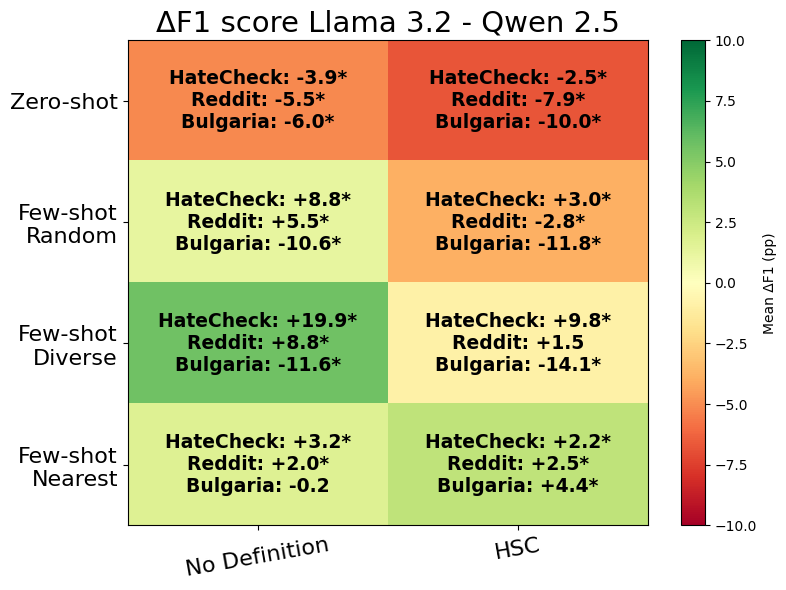

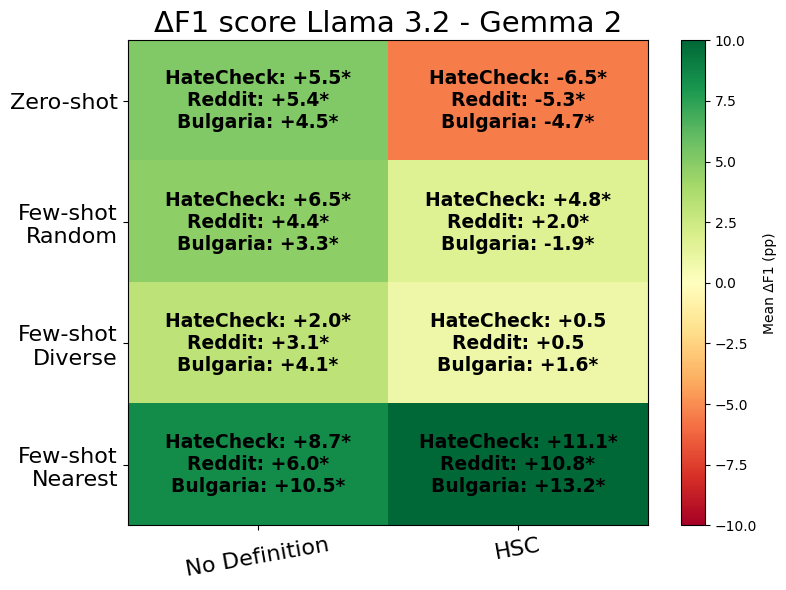

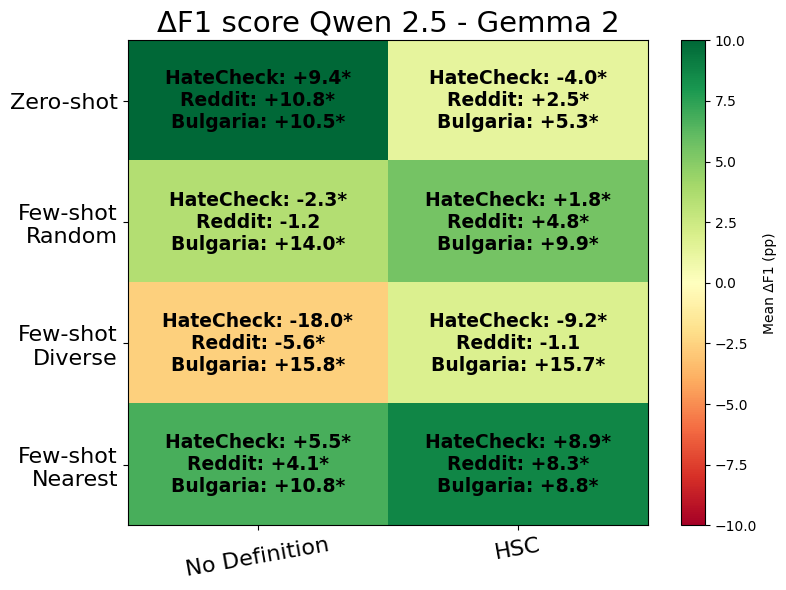

In [29]:
def model_cell_stats(frame, prompting, scope):
    return stats_by_dataset(
        lambda ds: first_row(frame, dataset=ds, definition=SCOPES[scope][ds], prompting=prompting)
    )


plot_comparison_heatmaps(
    models_significance_df,
    "model",
    PROMPTINGS,
    MERGED_DEFINITION_KEYS,
    model_cell_stats,
    [multiline_prompting_label(p) for p in PROMPTINGS],
    [MERGED_DEFINITION_LABELS[k] for k in MERGED_DEFINITION_KEYS],
    (8, 6),
)


## Definition comparisons

Compare `HSC` vs `No Definition` within each dataset variant (same model and prompting). Gold labels may differ across relabeled datasets, so those pairs do not require identical gold labels.


In [30]:
definition_rows = []
for model, prompting in tqdm(sorted({(m, p) for _, m, _, p in predictions}), desc="Definition pairs"):
    for def_a, def_b in DEFINITION_PAIRS:
        ds_a, ds_b = DATASET_BY_DEFINITION[def_a], DATASET_BY_DEFINITION[def_b]
        key_a, key_b = (ds_a, model, def_a, prompting), (ds_b, model, def_b, prompting)
        if key_a not in predictions or key_b not in predictions:
            continue
        definition_rows.append(
            {
                "model": model,
                "prompting": prompting,
                "comparison": f"{def_a} vs {def_b}",
                **paired_significance(
                    predictions[key_a], predictions[key_b], require_same_gold=(ds_a == ds_b)
                ),
            }
        )

definitions_significance_df = save_results(
    pd.DataFrame(definition_rows), "definitions_significance_test.csv"
)
definitions_significance_df.head()


Definition pairs: 100%|██████████| 12/12 [00:14<00:00,  1.17s/it]


,model,prompting,comparison,n_paired,f1_a,f1_b,delta_f1,mcnemar_b,mcnemar_c,mcnemar_p_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_value
0,gemma2_2b_it,few-shot-diverse,hatecheck_hsc vs hatecheck_no_definition,3634,0.8478,0.8552,-0.0073,34,57,2.109797e-02,-0.0134,-0.0013,0.0172
1,gemma2_2b_it,few-shot-diverse,reddit_hsc vs reddit_no_definition,3634,0.7509,0.7520,-0.0011,52,53,1.000000e+00,-0.0072,0.0049,0.7190
2,gemma2_2b_it,few-shot-diverse,bulgaria_hsc vs bulgaria_no_definition,3634,0.5766,0.5785,-0.0020,56,64,5.228167e-01,-0.0076,0.0038,0.5164
3,gemma2_2b_it,few-shot-nearest-query,hatecheck_hsc vs hatecheck_no_definition,3634,0.8095,0.8413,-0.0318,20,104,9.081330e-14,-0.0397,-0.0240,0.0000
4,gemma2_2b_it,few-shot-nearest-query,reddit_hsc vs reddit_no_definition,3634,0.7166,0.7458,-0.0292,30,118,8.592486e-13,-0.0368,-0.0218,0.0000


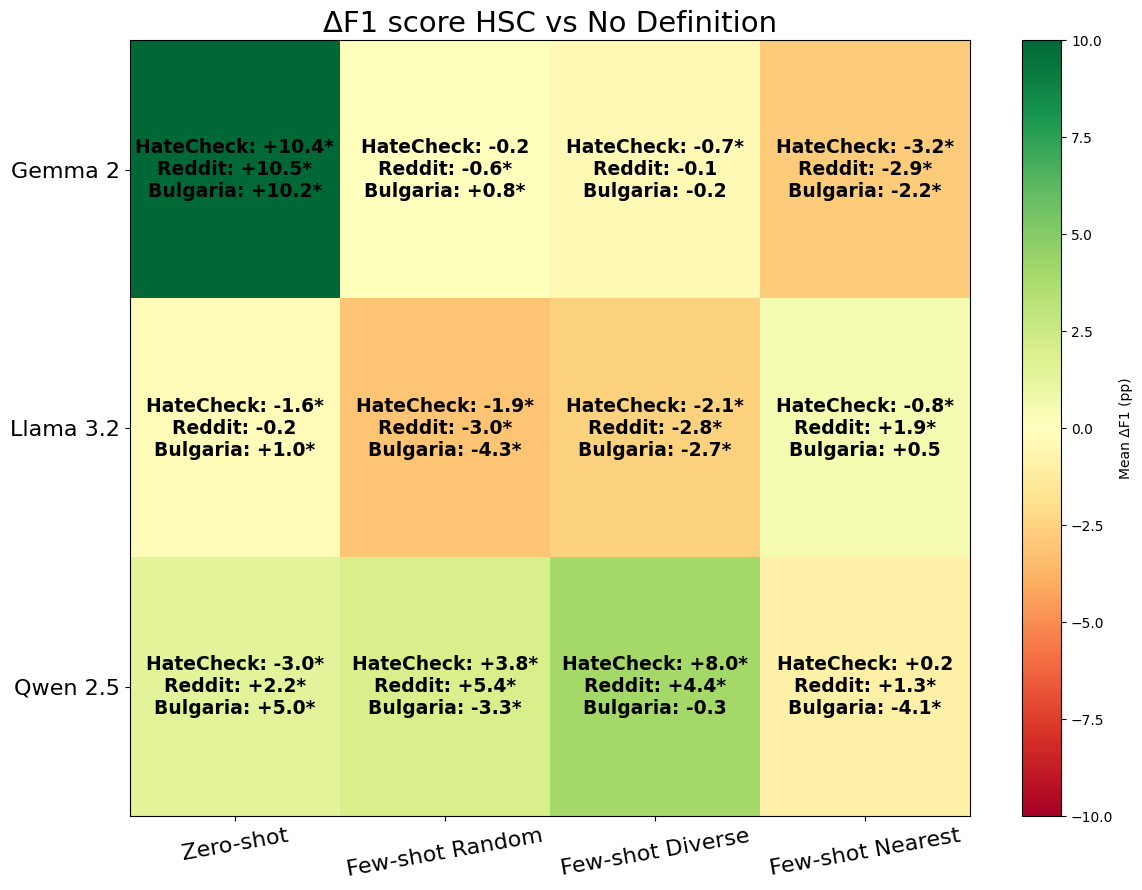

In [31]:
if definitions_significance_df.empty:
    print("No definition significance results to plot.")
else:
    matrix, texts = fill_merged_grid(
        MODELS,
        PROMPTINGS,
        lambda model, prompting: stats_by_dataset(
            lambda ds: first_row(
                definitions_significance_df,
                comparison=HSC_VS_NO_DEF[ds],
                model=model,
                prompting=prompting,
            )
        ),
    )
    plot_heatmap(
        matrix,
        texts,
        row_labels=[MODEL_LABELS[m] for m in MODELS],
        col_labels=[format_prompting_label(p) for p in PROMPTINGS],
        title="ΔF1 score HSC vs No Definition",
        outfile=FIGURES_DIR / "delta_f1_hsc_vs_no_definition.pdf",
        figsize=(12, 9),
    )


## Bulgaria: full HSC vs target-excluded HSC

Positive ΔF1 means the **target-excluded** definition (A) beats the standard Bulgaria HSC (B). This matches the paper table: excluded-target HSC − standard HSC.


Bulgaria HSC vs target-excluded: 100%|██████████| 12/12 [00:04<00:00,  2.56it/s]


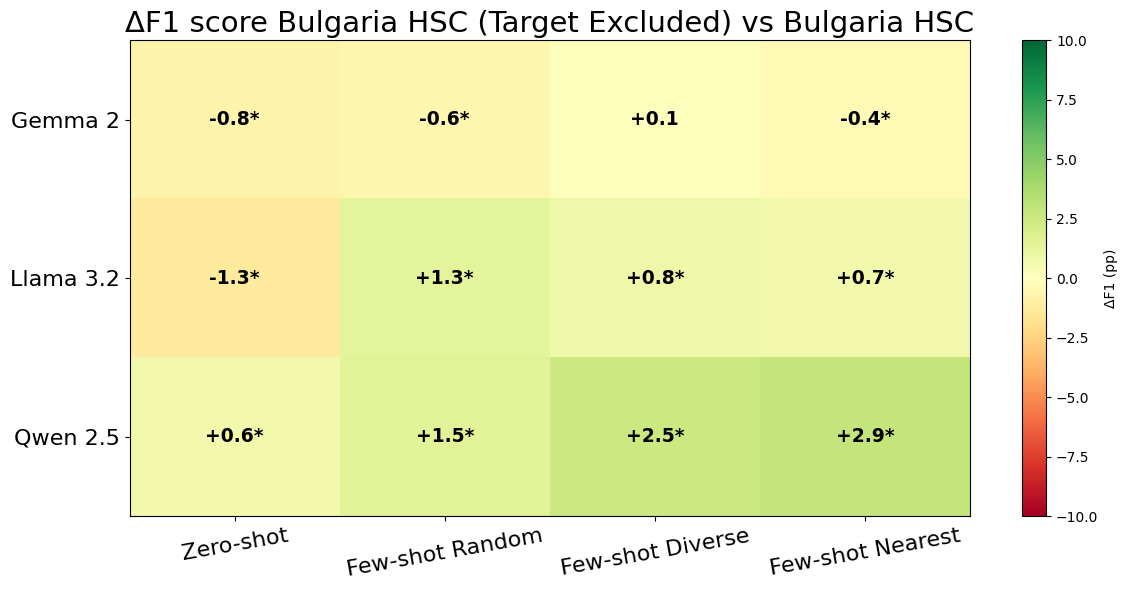

,model,prompting,f1_a,f1_b,delta_f1,bootstrap_p_value
2,gemma2_2b_it,few-shot-diverse,0.5776,0.5766,0.0010,0.4344
3,gemma2_2b_it,few-shot-nearest-query,0.5662,0.5700,-0.0038,0.0482
1,gemma2_2b_it,few-shot-random,0.5542,0.5599,-0.0057,0.0000
0,gemma2_2b_it,zero-shot,0.5357,0.5435,-0.0078,0.0000
6,llama3_2_3b_instruct,few-shot-diverse,0.6014,0.5933,0.0081,0.0004
7,llama3_2_3b_instruct,few-shot-nearest-query,0.7089,0.7024,0.0065,0.0016
5,llama3_2_3b_instruct,few-shot-random,0.5550,0.5416,0.0134,0.0000
4,llama3_2_3b_instruct,zero-shot,0.4835,0.4965,-0.0129,0.0000
10,qwen2_5_3b_instruct,few-shot-diverse,0.7588,0.7338,0.0250,0.0000
11,qwen2_5_3b_instruct,few-shot-nearest-query,0.6869,0.6584,0.0285,0.0000


In [32]:
BULGARIA, BULGARIA_HSC, BULGARIA_EXCLUDED = (
    "hatecheck_bulgaria",
    "bulgaria_hsc",
    "bulgaria_hsc_target_excluded",
)

bulgaria_hsc_significance_df = save_results(
    run_pair_grid(
        [(model, prompting) for model in MODELS for prompting in PROMPTINGS],
        [BULGARIA_HSC, BULGARIA_EXCLUDED],
        lambda ctx, a, b: ((BULGARIA, ctx[0], a, ctx[1]), (BULGARIA, ctx[0], b, ctx[1])),
        lambda ctx, a, b: {
            "dataset": BULGARIA,
            "model": ctx[0],
            "prompting": ctx[1],
            "comparison": f"{a} vs {b}",
        },
        "Bulgaria HSC vs target-excluded",
    ),
    "bulgaria_hsc_significance_test.csv",
)

if bulgaria_hsc_significance_df.empty:
    print("No Bulgaria results to plot.")
else:
    matrix = np.full((len(MODELS), len(PROMPTINGS)), np.nan)
    texts = [["" for _ in PROMPTINGS] for _ in MODELS]
    for i, model in enumerate(MODELS):
        for j, prompting in enumerate(PROMPTINGS):
            row = first_row(bulgaria_hsc_significance_df, model=model, prompting=prompting)
            if row is None:
                continue
            matrix[i, j] = row["delta_f1"] * 100
            texts[i][j] = format_pp(row["delta_f1"], row["bootstrap_p_value"])
    plot_heatmap(
        matrix,
        texts,
        row_labels=[MODEL_LABELS[m] for m in MODELS],
        col_labels=[format_prompting_label(p) for p in PROMPTINGS],
        title="ΔF1 score Bulgaria HSC (Target Excluded) vs Bulgaria HSC",
        outfile=FIGURES_DIR / "delta_f1_bulgaria_hsc_target_excluded_vs_bulgaria_hsc.pdf",
        figsize=(12, 6),
        colorbar_label="ΔF1 (pp)",
    )
    display(
        bulgaria_hsc_significance_df[
            ["model", "prompting", "f1_a", "f1_b", "delta_f1", "bootstrap_p_value"]
        ].sort_values(["model", "prompting"])
    )


## Prompting comparisons

For each (dataset, model, definition), compare every pair of prompting strategies.


In [33]:
promptings_significance_df = save_results(
    run_pair_grid(
        sorted({(d, m, definition) for d, m, definition, _ in predictions}),
        PROMPTINGS,
        lambda ctx, a, b: ((ctx[0], ctx[1], ctx[2], a), (ctx[0], ctx[1], ctx[2], b)),
        lambda ctx, a, b: {
            "dataset": ctx[0],
            "model": ctx[1],
            "definition": ctx[2],
            "comparison": f"{a} vs {b}",
        },
        "Prompting pairs",
    ),
    "promptings_significance_test.csv",
)
promptings_significance_df.head()


Prompting pairs: 100%|██████████| 21/21 [00:48<00:00,  2.33s/it]


,dataset,model,definition,comparison,n_paired,f1_a,f1_b,delta_f1,mcnemar_b,mcnemar_c,mcnemar_p_value,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_value
0,hatecheck,gemma2_2b_it,hatecheck_hsc,few-shot-nearest-query vs few-shot-diverse,3634,0.8095,0.8478,-0.0383,168,255,2.896393e-05,-0.0520,-0.0250,0.0000
1,hatecheck,gemma2_2b_it,hatecheck_hsc,few-shot-nearest-query vs few-shot-random,3634,0.8095,0.7867,0.0228,182,119,3.520790e-04,0.0104,0.0356,0.0002
2,hatecheck,gemma2_2b_it,hatecheck_hsc,few-shot-nearest-query vs zero-shot,3634,0.8095,0.8453,-0.0358,168,256,2.388416e-05,-0.0501,-0.0219,0.0000
3,hatecheck,gemma2_2b_it,hatecheck_hsc,few-shot-diverse vs few-shot-random,3634,0.8478,0.7867,0.0611,222,72,3.628977e-18,0.0497,0.0726,0.0000
4,hatecheck,gemma2_2b_it,hatecheck_hsc,few-shot-diverse vs zero-shot,3634,0.8478,0.8453,0.0025,87,88,1.000000e+00,-0.0060,0.0109,0.5716


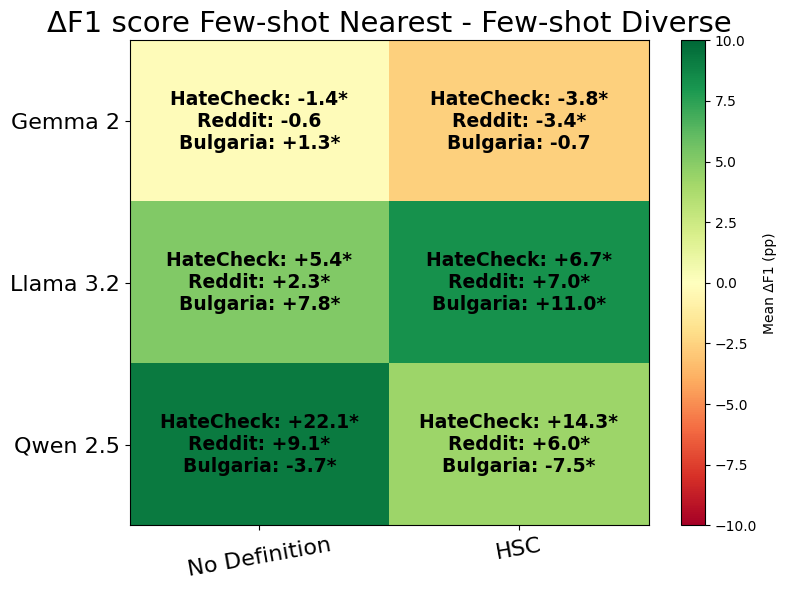

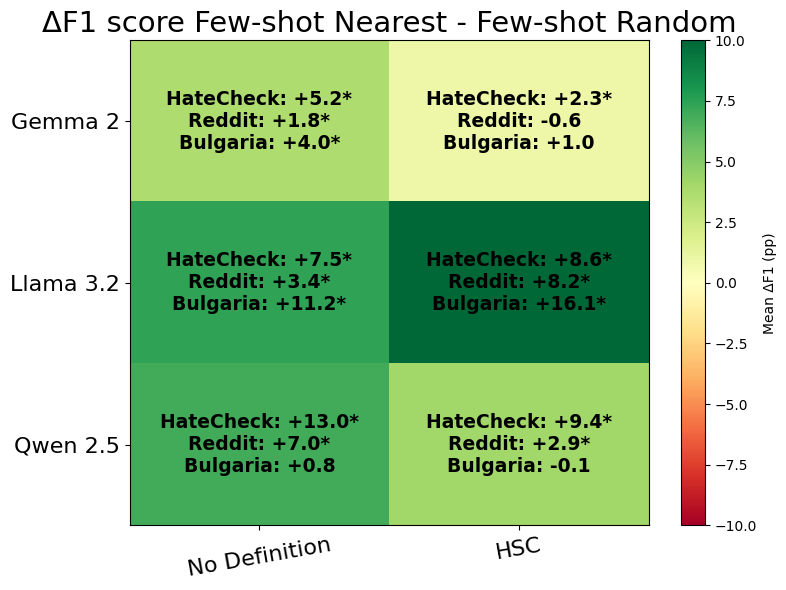

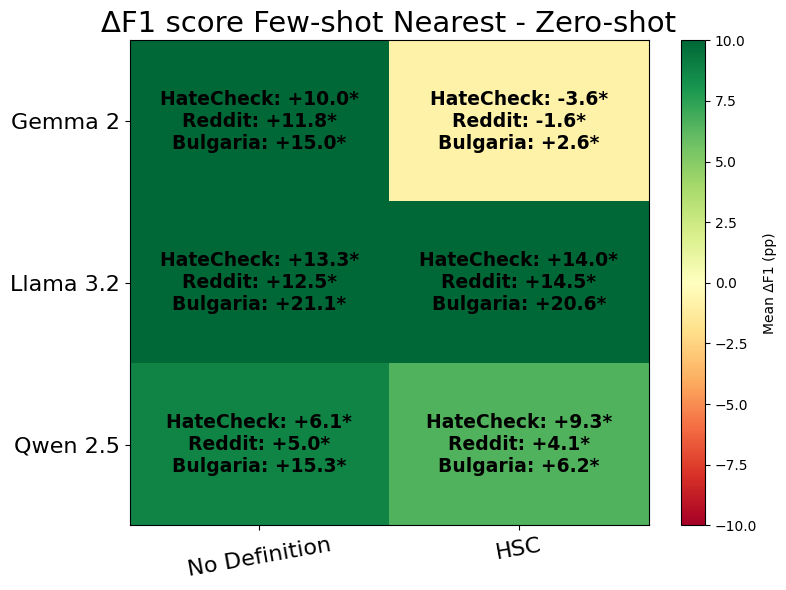

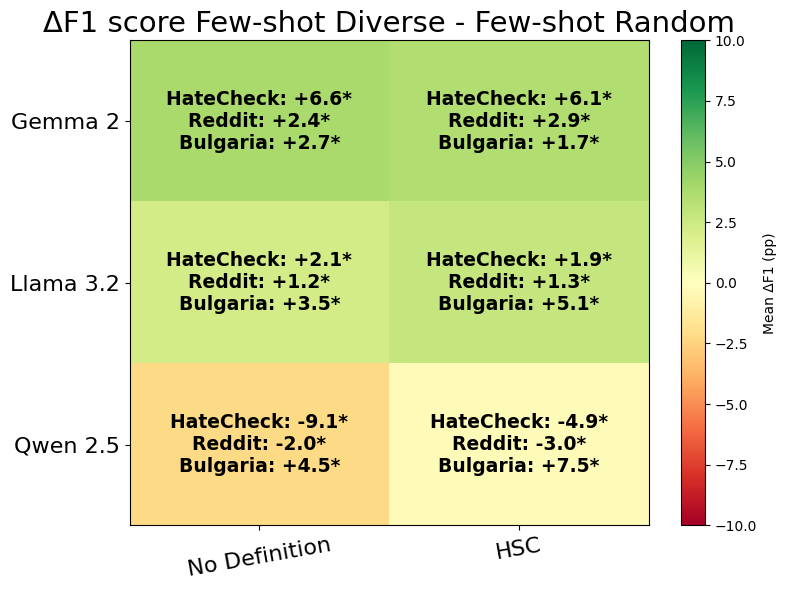

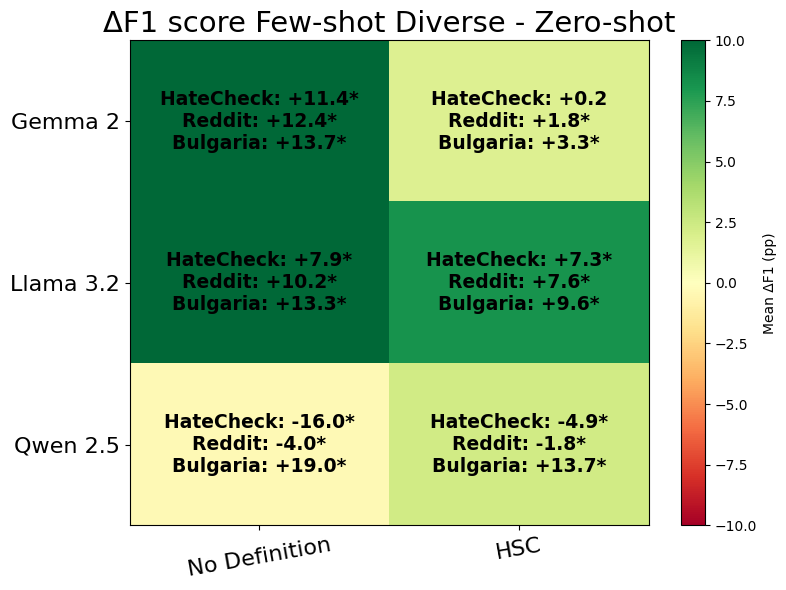

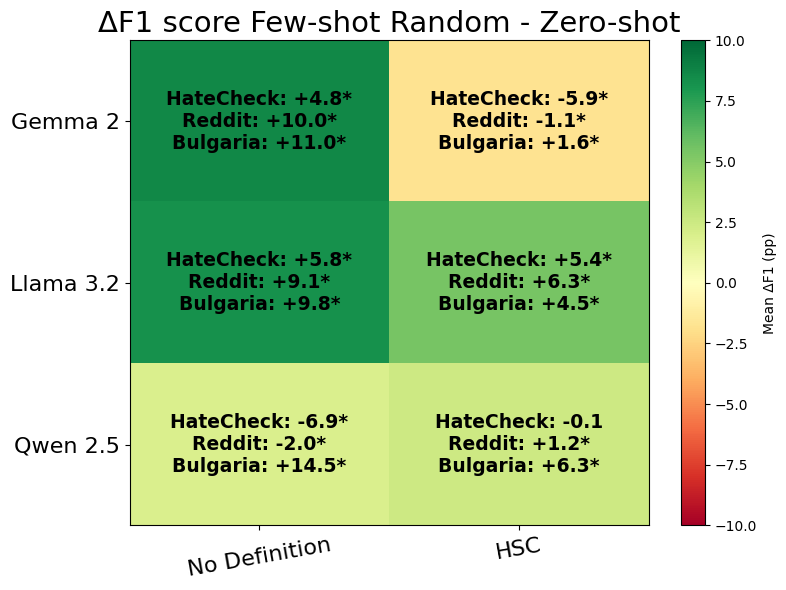

In [34]:
def prompting_cell_stats(frame, model, scope):
    return stats_by_dataset(
        lambda ds: first_row(frame, dataset=ds, model=model, definition=SCOPES[scope][ds])
    )


plot_comparison_heatmaps(
    promptings_significance_df,
    "prompting",
    MODELS,
    MERGED_DEFINITION_KEYS,
    prompting_cell_stats,
    [MODEL_LABELS[m] for m in MODELS],
    [MERGED_DEFINITION_LABELS[k] for k in MERGED_DEFINITION_KEYS],
    (8, 6),
)
